# Notebook 01 · Data Quality, Proxies, and Gap Characterization

This notebook executes **Phase A, Step 1** of the `heritageshm` pipeline:

1. **Sensor Loading** — Load the preprocessed sensor CSV from Notebook 00.
2. **Proxy Loading** — Explicitly load specific environmental proxies (e.g. Skin Temperature, Air Temp).
3. **Alignment** — Resample and synchronize multiple proxies onto the sensor index.
4. **Gap Characterization** — Classify missing data and diagnose gap taxonomy.
5. **Save** — Export the aligned, cleaned dataset to `/data/interim/aligned/`.

In [1]:
import sys
import os
import pandas as pd
from IPython.display import display

sys.path.insert(0, os.path.abspath('..'))

from heritageshm.dataloader import load_preprocessed_sensor, load_proxy_data, save_interim_data
from heritageshm.preprocessing import align_multiple_proxies
from heritageshm.diagnostics import characterize_gaps
from heritageshm.viz import apply_theme

apply_theme(context='notebook')

## Step 1 · Load Preprocessed Sensor Data

### Parameter Tuning Guidance

**TARGET_STATION**: Change this to match your sensor station identifier. The file naming convention expects
`{station}_preprocessed.csv` in the `/data/interim/sensor/` directory.

**Tips**:
- Ensure you've run Notebook 00 first to generate the preprocessed sensor file.
- Common station IDs: 'st01', 'st02', 'st03', etc.
- If loading fails, verify the file exists at the expected path.

In [2]:
TARGET_STATION = 'st02'

SENSOR_FILE = f'data/interim/sensor/{TARGET_STATION}_preprocessed.csv'
df_sensor = load_preprocessed_sensor(SENSOR_FILE)

print(f"Loaded {TARGET_STATION} sensor dataset: {df_sensor.shape}")
print(f"Sensor date range: {df_sensor.index.min()} → {df_sensor.index.max()}")
df_sensor.head(3)

Loaded st02 sensor dataset: (115895, 5)
Sensor date range: 2018-07-25 23:40:00 → 2025-02-05 12:20:00


,charge,temp,hum,absinc_raw,absinc
datetime,,,,,
2018-07-25 23:40:00,3.49,21.750,45.115,2122.750,0.000
2018-07-26 00:00:00,3.47,21.555,45.155,2122.125,0.350
2018-07-26 00:20:00,3.47,21.365,45.040,2121.000,0.175


## Step 2 · Load Proxies Individually
Fetch any environmental proxy data you want to associate with the sensor.

In [3]:
PROXY_FILE = 'data/raw/proxies/oikolab_weather.csv'

# Peek at the columns without loading the entire file into memory
sample_df = pd.read_csv(PROXY_FILE, nrows=0)
print("Available columns in the proxy file:")
for col in sample_df.columns:
    print(f"  - {col}")

Available columns in the proxy file:
  - datetime (UTC)
  - coordinates (lat,lon)
  - model (name)
  - model elevation (surface)
  - utc_offset (hrs)
  - temperature (degC)
  - dewpoint_temperature (degC)
  - relative_humidity (0-1)
  - wetbulb_temperature (degC)
  - skin_temperature (degC)
  - urban_temperature (degC)
  - wind_speed (m/s)
  - wind_direction (deg)
  - total_cloud_cover (0-1)
  - total_precipitation (mm of water equivalent)
  - surface_solar_radiation (W/m^2)
  - surface_thermal_radiation (W/m^2)


### Parameter Tuning Guidance

**PROXY_FILE**: Update this path to point to your environmental proxy data file. Supported formats include CSV files from:
- ERA5 reanalysis data
- Local weather station data
- Satellite-derived climate proxies

**Tips**:
- Proxy files should have a 'datetime (UTC)' column for automatic parsing.
- Place proxy files in `/data/raw/proxies/`.
- Multiple proxy sources can be loaded by duplicating this cell with different file paths.

In [4]:
# === USER INPUT ===
PROXY_FILE = 'data/raw/proxies/oikolab_weather.csv'

# Select only the proxy columns you want to use downstream.
# Remove or comment out any you don't need.
PROXY_COLS = [
    'temperature (degC)',
    'dewpoint_temperature (degC)',
    'relative_humidity (0-1)',
    'wetbulb_temperature (degC)',
    'skin_temperature (degC)',
    'urban_temperature (degC)',
    # 'wind_speed (m/s)',
    # 'wind_direction (deg)',
    # 'total_cloud_cover (0-1)',
    # 'total_precipitation (mm of water equivalent)',
    'surface_solar_radiation (W/m^2)',
    'surface_thermal_radiation (W/m^2)',
]
# ==================

# Metadata columns to always drop
META_COLS = ['coordinates (lat,lon)', 'model (name)',
             'model elevation (surface)', 'utc_offset (hrs)']

# Load
df_proxy = pd.read_csv(PROXY_FILE,
                       parse_dates=['datetime (UTC)'],
                       index_col='datetime (UTC)')
df_proxy.index.name = 'datetime'

# Drop metadata, keep only selected signals
df_proxy = df_proxy.drop(columns=[c for c in META_COLS if c in df_proxy.columns])
df_proxy = df_proxy[[c for c in PROXY_COLS if c in df_proxy.columns]]

print(f"Loaded proxy dataset: {df_proxy.shape}")
print(f"Proxy date range: {df_proxy.index.min()} → {df_proxy.index.max()}")
display(df_proxy.head(3))

# Build the proxies_dict expected by align_multiple_proxies()
proxies_dict = {'oikolab': df_proxy}
print(f"\nLoaded {len(proxies_dict)} proxy dataset(s).")

Loaded proxy dataset: (72628, 8)
Proxy date range: 2018-01-01 00:00:00 → 2026-04-16 21:00:00


,temperature (degC),dewpoint_temperature (degC),relative_humidity (0-1),wetbulb_temperature (degC),skin_temperature (degC),urban_temperature (degC),surface_solar_radiation (W/m^2),surface_thermal_radiation (W/m^2)
datetime,,,,,,,,
2018-01-01 00:00:00,7.15,5.91,0.92,6.28,6.29,7.14,0.0,320.89
2018-01-01 01:00:00,7.97,6.58,0.91,7.01,6.72,7.55,0.0,335.55
2018-01-01 02:00:00,7.89,6.05,0.88,6.67,7.42,7.54,0.0,336.98



Loaded 1 proxy dataset(s).


### Parameter Tuning Guidance

**PROXY_COLS**: Select environmental variables that have physical relevance to your structural response.
The grey-box model in Notebook 04 will use these as exogenous regressors.

**Selection Guidelines**:
- **Temperature proxies** (`temperature`, `skin_temperature`, `urban_temperature`): Critical for thermal expansion/contraction effects.
- **Radiation proxies** (`surface_solar_radiation`, `surface_thermal_radiation`): Important for structures with significant thermal mass.
- **Humidity proxies** (`relative_humidity`, `dewpoint_temperature`): Relevant for moisture-sensitive materials.
- **Wind proxies** (`wind_speed`, `wind_direction`): Useful for tall/slender structures.

**Tips**:
- Start with temperature and radiation variables for masonry/stone structures.
- Use cointegration tests in Notebook 02 to validate proxy selection.
- Fewer, well-chosen proxies improve model interpretability.
- Uncomment additional columns based on your structure type.

## Step 2b · Proxy Temporal Coverage Check
Verify that the proxy data fully covers the sensor monitoring period before alignment.
A silent temporal mismatch would produce NaN-filled proxy columns with no downstream warning.

In [5]:
sensor_start, sensor_end = df_sensor.index.min(), df_sensor.index.max()
proxy_start,  proxy_end  = df_proxy.index.min(),  df_proxy.index.max()

coverage_ok = (proxy_start <= sensor_start) and (proxy_end >= sensor_end)

print(f"Sensor window : {sensor_start} → {sensor_end}")
print(f"Proxy window  : {proxy_start} → {proxy_end}")

if coverage_ok:
    print("✓ Proxy data fully covers the sensor monitoring period.")
else:
    if proxy_start > sensor_start:
        print(f"⚠ WARNING: Proxy starts {proxy_start - sensor_start} after sensor start. "
              f"Sensor data before {proxy_start} will have NaN proxies.")
    if proxy_end < sensor_end:
        print(f"⚠ WARNING: Proxy ends {sensor_end - proxy_end} before sensor end. "
              f"Sensor data after {proxy_end} will have NaN proxies.")

assert coverage_ok, (
    "Proxy temporal coverage is insufficient. Extend the proxy extraction period "
    "to fully bracket the sensor monitoring window before proceeding."
)

Sensor window : 2018-07-25 23:40:00 → 2025-02-05 12:20:00
Proxy window  : 2018-01-01 00:00:00 → 2026-04-16 21:00:00
✓ Proxy data fully covers the sensor monitoring period.


## Step 3 · Resampling and Alignment
Using `align_multiple_proxies`, we resample all defined proxies to match the desired monitoring frequency.

### Parameter Tuning Guidance

**TARGET_FREQ**: Sets the resampling frequency for aligning sensor and proxy data. Common options:
- `'h'` (hourly): Recommended for most SHM applications; balances detail with computational efficiency.
- `'30min'` or `'15min'`: Higher resolution for fast dynamic responses.
- `'2h'` or `'3h'`: Lower resolution for slow thermal responses or long-term monitoring.

**Tips**:
- Hourly (`'h'`) is the default and works well for masonry/stone structures.
- Use finer resolution only if your analysis requires capturing rapid environmental changes.
- Ensure proxy data has sufficient resolution for your chosen frequency.

In [6]:
TARGET_FREQ = 'h'  # Hourly

if proxies_dict:
    df_aligned = align_multiple_proxies(df_sensor, proxies_dict, resample_freq=TARGET_FREQ, add_prefix=False)
else:
    print("No proxies loaded. Proceeding with sensor data only.")
    df_aligned = df_sensor.resample(TARGET_FREQ).mean()

print(f"Aligned dataset shape: {df_aligned.shape}")
df_aligned.head(3)

Resampling sensor data to h...
Complete index: 57278 time steps (2018-07-25 23:00:00 → 2025-02-05 12:00:00)
Sensor NaN rows (gaps): 17664
Resampling proxy 'oikolab' to h...
Merging 'oikolab'...
Final aligned dataset contains 57278 rows.
Aligned dataset shape: (57278, 13)


,charge,temp,hum,absinc_raw,absinc,temperature (degC),dewpoint_temperature (degC),relative_humidity (0-1),wetbulb_temperature (degC),skin_temperature (degC),urban_temperature (degC),surface_solar_radiation (W/m^2),surface_thermal_radiation (W/m^2)
datetime,,,,,,,,,,,,,
2018-07-25 23:00:00,3.490000,21.750000,45.115000,2122.750000,0.000000,19.11,14.68,0.75,16.13,18.01,22.94,0.0,340.73
2018-07-26 00:00:00,3.473333,21.356667,44.898333,2121.333333,0.550000,18.76,14.93,0.78,16.15,17.32,22.55,0.0,338.83
2018-07-26 01:00:00,3.470000,20.861667,45.828333,2120.125000,1.816667,18.62,15.05,0.80,16.17,16.76,22.25,0.0,339.00


### Step 3b · Post-Alignment Validation
Inspect the missing-data fraction per column immediately after alignment.
This catches silent alignment failures (e.g., index mismatches, unit mismatches, or insufficient proxy coverage)
before they propagate to downstream notebooks.

In [7]:
missing_frac = df_aligned.isnull().mean().rename('missing_frac').to_frame()
missing_frac['missing_pct'] = (missing_frac['missing_frac'] * 100).round(2)
missing_frac['n_missing'] = df_aligned.isnull().sum()

print("--- Post-Alignment Missingness Summary ---")
display(missing_frac.sort_values('missing_frac', ascending=False))

# Warn if any proxy column is entirely NaN (total coverage failure)
fully_missing = missing_frac[missing_frac['missing_frac'] == 1.0].index.tolist()
if fully_missing:
    raise ValueError(
        f"The following columns are entirely NaN after alignment — "
        f"check index compatibility and proxy coverage: {fully_missing}"
    )

--- Post-Alignment Missingness Summary ---


,missing_frac,missing_pct,n_missing
charge,0.308391,30.84,17664
temp,0.308391,30.84,17664
hum,0.308391,30.84,17664
absinc_raw,0.308391,30.84,17664
absinc,0.308391,30.84,17664
temperature (degC),0.000000,0.00,0
dewpoint_temperature (degC),0.000000,0.00,0
relative_humidity (0-1),0.000000,0.00,0
wetbulb_temperature (degC),0.000000,0.00,0
skin_temperature (degC),0.000000,0.00,0


## Step 4 · Gap Characterization and Final Save
Diagnose the gaps in the primary structural signal, export the figure and statistics table,
then save the unified dataset for downstream analysis.

### Parameter Tuning Guidance

**TARGET_COL**: The structural response variable to analyze for data gaps.

**Selection Guidelines**:
- Choose the main structural response variable (e.g., inclination, strain, displacement).
- This variable will be the target for imputation in Notebook 03.
- Common choices: `absinc` (absolute inclination), `strain`, `displacement`.

**max_impute_gap** (in `characterize_gaps`): Threshold for classifying gap severity.
- `0` (default): Classifies all gaps regardless of length; no interpolation is applied.
- Set to a positive integer to linearly interpolate gaps shorter than this threshold.

**HISTOGRAM_BINS**: Controls the number of bins in the gap length distribution histogram.
- Default: 50 bins. Adjust between 20 (coarser) and 100 (finer) depending on gap diversity.

**Interpreting Gap Taxonomy**:
- **MCAR**: Gaps occur randomly; simpler imputation methods work well.
- **MAR**: Gaps related to observed variables; use regression-based methods.
- **MNAR**: Gaps related to unobserved factors; requires advanced methods (XGBoost, BiLSTM).

In [8]:
TARGET_COL     = 'absinc'  # The main signal to check for gaps
HISTOGRAM_BINS = 50        # Number of bins for gap length distribution

GAP_FIG_PATH = f'outputs/figures/01_01_{TARGET_STATION}_gap_histogram.png'
GAP_TAB_PATH = f'outputs/tables/01_01_{TARGET_STATION}_gap_stats.csv'
ALIGNED_PATH  = f'data/interim/aligned/{TARGET_STATION}_aligned_dataset.csv'

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables',  exist_ok=True)
os.makedirs(os.path.dirname(ALIGNED_PATH), exist_ok=True)


--- Gap Taxonomy for 'absinc' ---
Total Gaps Detected: 452
Average Gap Length:  39.08 time steps
Maximum Gap Length:  10502 time steps
Minimum Gap Length:  1 time steps
Gap Length Std Dev:  507.23 time steps

Histogram Bin Intervals (50 bins):
Bin width: 210.0 time steps
  Bin  1: [   1.0,  211.0) time steps
  Bin  2: [ 211.0,  421.0) time steps
  Bin  3: [ 421.0,  631.1) time steps
  Bin  4: [ 631.1,  841.1) time steps
  Bin  5: [ 841.1, 1051.1) time steps
  Bin  6: [1051.1, 1261.1) time steps
  Bin  7: [1261.1, 1471.1) time steps
  Bin  8: [1471.1, 1681.2) time steps
  Bin  9: [1681.2, 1891.2) time steps
  Bin 10: [1891.2, 2101.2) time steps
  Bin 11: [2101.2, 2311.2) time steps
  Bin 12: [2311.2, 2521.2) time steps
  Bin 13: [2521.2, 2731.3) time steps
  Bin 14: [2731.3, 2941.3) time steps
  Bin 15: [2941.3, 3151.3) time steps
  Bin 16: [3151.3, 3361.3) time steps
  Bin 17: [3361.3, 3571.3) time steps
  Bin 18: [3571.3, 3781.4) time steps
  Bin 19: [3781.4, 3991.4) time steps
  Bin

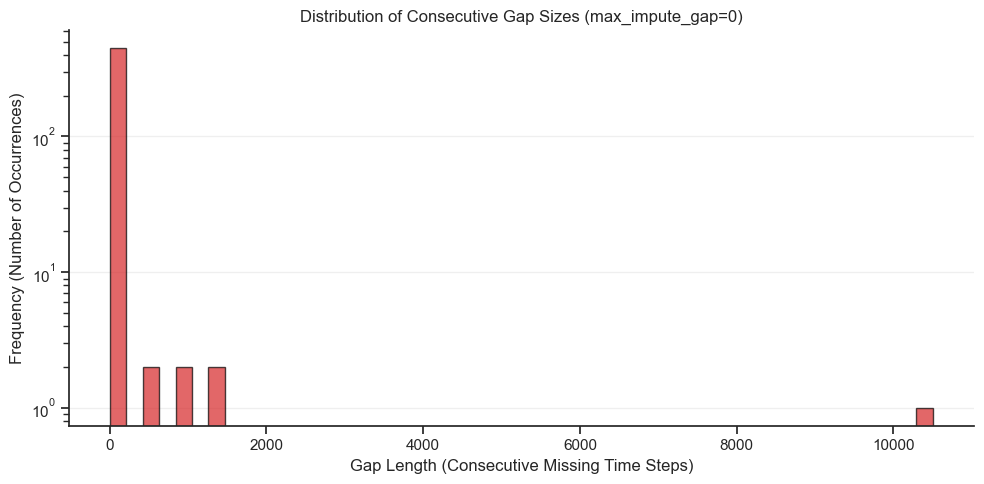

In [9]:
gap_characterization_ok = False

try:
    df_aligned, gap_stats, gap_lengths = characterize_gaps(
        df_aligned,
        target_col=TARGET_COL,
        max_impute_gap=0,
        histogram_bins=HISTOGRAM_BINS,
        save_plot_path=GAP_FIG_PATH,
    )
    gap_characterization_ok = True

except Exception as e:
    print(f"⚠ Gap characterization failed: {e}")
    print("The aligned dataset will NOT be saved. Resolve the error before proceeding.")

### Gap Statistics Summary
Display and export the full gap statistics table for reference in the paper.

In [10]:
if gap_characterization_ok:
    total_obs    = len(df_aligned)
    total_missing = df_aligned[TARGET_COL].isnull().sum()
    missing_pct  = total_missing / total_obs * 100

    print(f"\n--- Gap Statistics Summary for '{TARGET_COL}' ---")
    print(f"Total observations : {total_obs}")
    print(f"Total missing      : {total_missing} ({missing_pct:.2f}%)")
    display(gap_stats.rename('value').to_frame())

    # Export gap stats as a paper-ready CSV table
    gap_stats_export = gap_stats.rename('value').to_frame()
    gap_stats_export.loc['total_missing_pct'] = missing_pct
    gap_stats_export.to_csv(GAP_TAB_PATH)
    print(f"\nGap statistics saved to: {GAP_TAB_PATH}")
    print(f"Gap histogram saved to : {GAP_FIG_PATH}")


--- Gap Statistics Summary for 'absinc' ---
Total observations : 57278
Total missing      : 17664 (30.84%)


,value
count,452.000000
mean,39.079646
std,507.230206
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,10502.000000



Gap statistics saved to: outputs/tables/01_01_st02_gap_stats.csv
Gap histogram saved to : outputs/figures/01_01_st02_gap_histogram.png


## Step 5 · Save Aligned Dataset
Only saves if gap characterization completed successfully.

In [11]:
if gap_characterization_ok:
    save_interim_data(df_aligned, ALIGNED_PATH)
    print(f"Aligned dataset saved to: {ALIGNED_PATH}")
else:
    print("Save skipped — gap characterization did not complete successfully.")

Interim data successfully saved to data/interim/aligned/st02_aligned_dataset.csv
Aligned dataset saved to: data/interim/aligned/st02_aligned_dataset.csv
